### This notebook investigates customer segments, transaction types, amounts, channels, status, international transactions, customer behaviour, and risk-review patterns, following on from the Part A Excel data-quality assessment and Part B SQL analysis.

In [2]:
## import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)

In [7]:
## load the data
customers = pd.read_csv("FinTrust_Customer_Data - FinTrust_Customer_Data.csv")
transactions = pd.read_csv("FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv")

In [8]:
## verify the tables
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)
customers.head()

Customers: (1500, 12)
Transactions: (12000, 11)


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [9]:
## explicit month/day/year parsing (locale-proof)
transactions['Transaction_DateTime'] = pd.to_datetime(
    transactions['Transaction_DateTime'], format='%m/%d/%Y %H:%M')

#  fill missing categorical values
transactions['Device_Type'] = transactions['Device_Type'].fillna('Unknown')
transactions['Location'] = transactions['Location'].fillna('Unknown')

# Derived fields useful for the EDA below
transactions['Hour'] = transactions['Transaction_DateTime'].dt.hour
transactions['DayOfWeek'] = transactions['Transaction_DateTime'].dt.day_name()

# Join for analyses that need customer attributes alongside transactions
txn_full = transactions.merge(customers, on='Customer_ID', how='left')

print("Missing values remaining:", transactions[['Device_Type','Location']].isna().sum().sum())
transactions.dtypes

Missing values remaining: 0


Transaction_ID                       object
Customer_ID                          object
Transaction_DateTime         datetime64[ns]
Transaction_Type                     object
Amount_NGN                          float64
Channel                              object
Device_Type                          object
Location                             object
International_Transaction            object
Transaction_Status                   object
Risk_Review_Flag                     object
Hour                                  int32
DayOfWeek                            object
dtype: object

Customer_Segment
Everyday    711
Premium     295
Student     278
SME         216
Name: count, dtype: int64


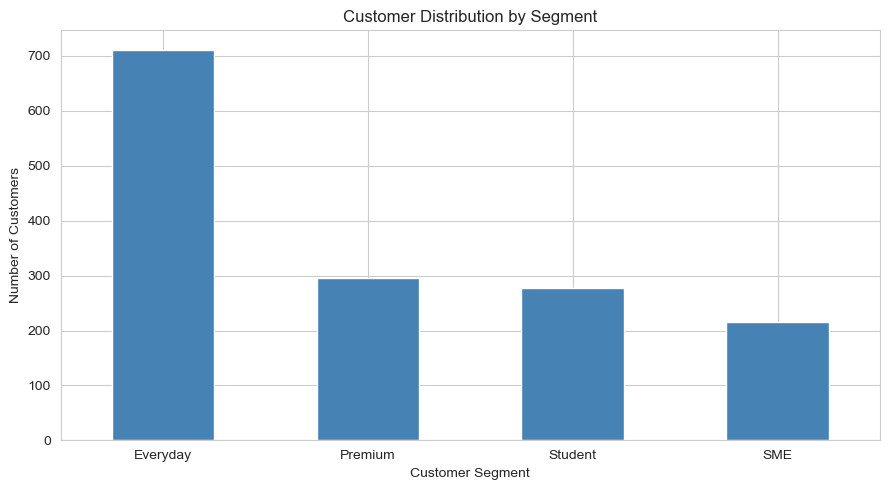

In [10]:
## Visualization 1- Customer Segment Distribution (What it shows: how many customers fall into each segment.
# Why it matters: segment sizes shape how much analytical and product development weight each segment should get.)

segment_counts = customers['Customer_Segment'].value_counts()
print(segment_counts)

plt.figure()
segment_counts.plot(kind='bar', color='steelblue')
plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Transaction_Type
Transfer           3549
Card Purchase      3033
Bill Payment       1475
Cash Withdrawal    1430
Deposit            1328
Airtime/Data       1185
Name: count, dtype: int64
Transaction_Type
Transfer           2.379167e+08
Card Purchase      8.586341e+07
Bill Payment       2.816365e+07
Cash Withdrawal    6.777236e+07
Deposit            1.309851e+08
Airtime/Data       9.776171e+06
Name: Amount_NGN, dtype: float64


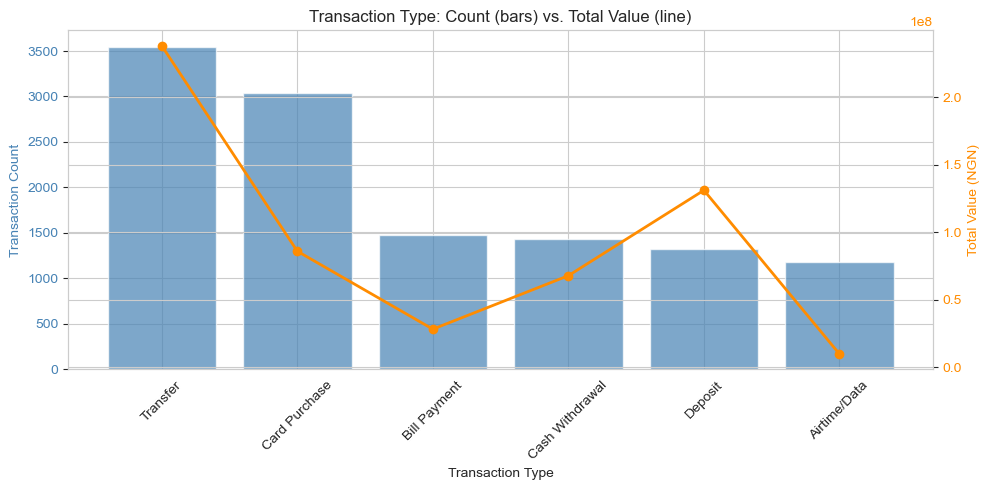

In [11]:
## Visualization 2 — Transaction Type: Count vs. Value
# it shows how many transactions fall into each type, and how much total value each type represents.

type_counts = transactions['Transaction_Type'].value_counts()
type_totals = transactions.groupby('Transaction_Type')['Amount_NGN'].sum().reindex(type_counts.index)

print(type_counts)
print(type_totals)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(type_counts.index, type_counts.values, color='steelblue', alpha=0.7)
ax1.set_ylabel('Transaction Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel('Transaction Type')

ax2 = ax1.twinx()
ax2.plot(type_totals.index, type_totals.values, color='darkorange', marker='o', linewidth=2)
ax2.set_ylabel('Total Value (NGN)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Transaction Type: Count (bars) vs. Total Value (line)')
fig.tight_layout()
plt.show()

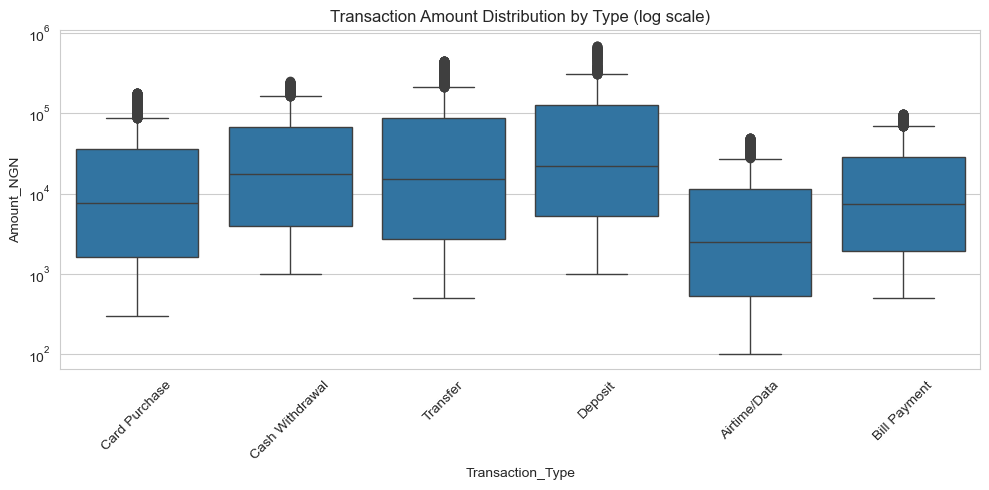

count     12000.000000
mean      46706.446238
std       86028.715234
min         100.170000
25%        2192.220000
50%       10305.935000
75%       48484.475000
max      693454.450000
Name: Amount_NGN, dtype: float64


In [13]:
## Visualization 3 — Transaction Amount Distribution
## What it shows: the overall spread of Amount_NGN, and how that spread differs by Transaction_Type.

plt.figure(figsize=(10, 5))
sns.boxplot(data=transactions, x='Transaction_Type', y='Amount_NGN')
plt.yscale('log')
plt.title('Transaction Amount Distribution by Type (log scale)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(transactions['Amount_NGN'].describe())

Channel
Mobile App    5102
POS           2393
Web           1869
ATM           1747
USSD           889
Name: count, dtype: int64
Channel
Mobile App    89.749118
POS           90.848308
Web           90.850722
ATM           91.700057
USSD          90.326209
Name: Transaction_Status, dtype: float64


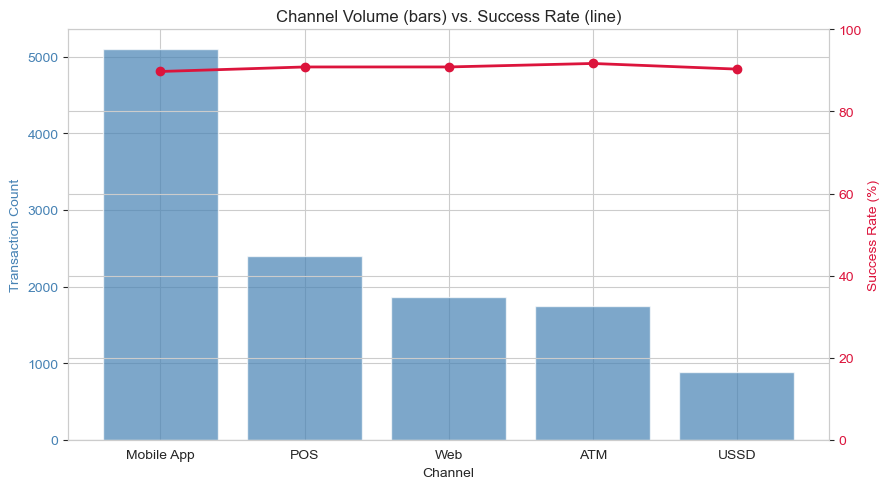

In [14]:
## Visualization 4 — Channel Volume and Success Rate
# What it shows: how many transactions each channel handles, and what share of each channel's transactions succeed.

channel_counts = transactions['Channel'].value_counts()
success_rate_by_channel = transactions.groupby('Channel')['Transaction_Status'].apply(
    lambda s: (s == 'Successful').mean() * 100
).reindex(channel_counts.index)

print(channel_counts)
print(success_rate_by_channel)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(channel_counts.index, channel_counts.values, color='steelblue', alpha=0.7)
ax1.set_ylabel('Transaction Count', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Channel')

ax2 = ax1.twinx()
ax2.plot(channel_counts.index, success_rate_by_channel.values, color='crimson', marker='o', linewidth=2)
ax2.set_ylabel('Success Rate (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 100)

plt.title('Channel Volume (bars) vs. Success Rate (line)')
fig.tight_layout()
plt.show()

Transaction_Status
Successful    10856
Failed          630
Reversed        326
Pending         188
Name: count, dtype: int64


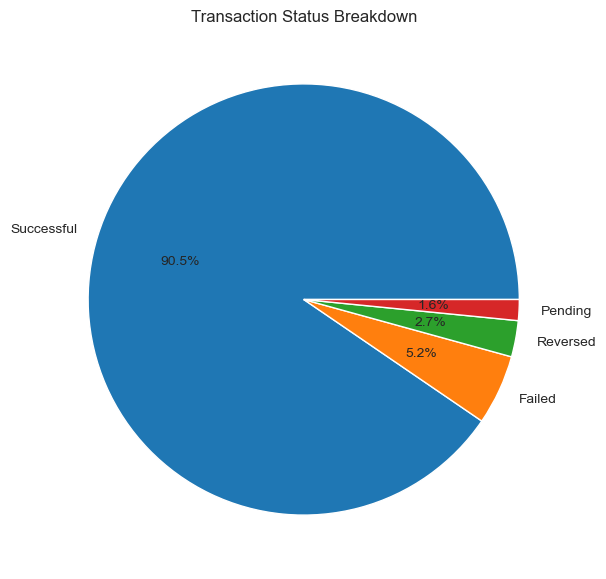

In [15]:
## Visualization 5 — Transaction Status Breakdown
# What it shows: the overall split between Successful, Failed, Pending, and Reversed transactions.

status_counts = transactions['Transaction_Status'].value_counts()
print(status_counts)

plt.figure(figsize=(7, 7))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Transaction Status Breakdown')
plt.show()

Average amount (NGN):
International_Transaction
No     46916.803036
Yes    41657.883063
Name: Amount_NGN, dtype: float64


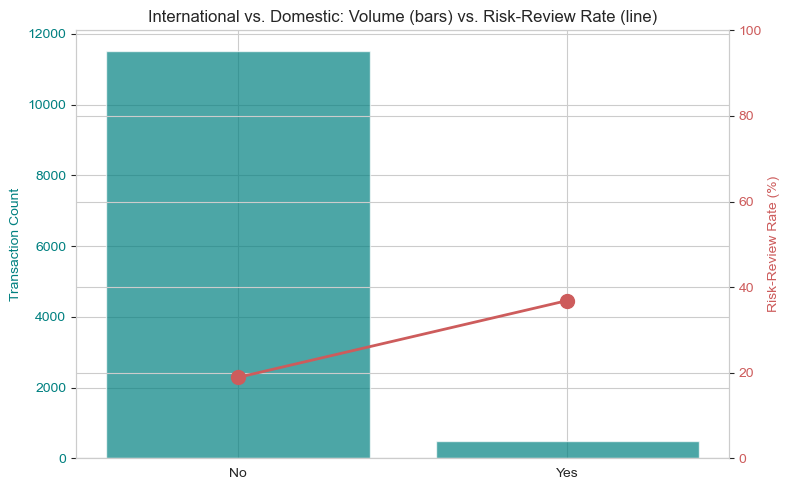

In [16]:
## Visualization 6 — International vs. Domestic Transactions
# What it shows: how international transactions compare to domestic ones on count, average value, and risk-review rate.

intl_counts = transactions['International_Transaction'].value_counts()
intl_avg_amount = transactions.groupby('International_Transaction')['Amount_NGN'].mean()
intl_risk_rate = transactions.groupby('International_Transaction')['Risk_Review_Flag'].apply(
    lambda s: (s == 'Yes').mean() * 100
).reindex(intl_counts.index)

print("Average amount (NGN):")
print(intl_avg_amount)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(intl_counts.index, intl_counts.values, color='teal', alpha=0.7)
ax1.set_ylabel('Transaction Count', color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(intl_counts.index, intl_risk_rate.values, color='indianred', marker='o', linewidth=2, markersize=10)
ax2.set_ylabel('Risk-Review Rate (%)', color='indianred')
ax2.tick_params(axis='y', labelcolor='indianred')
ax2.set_ylim(0, 100)

plt.title('International vs. Domestic: Volume (bars) vs. Risk-Review Rate (line)')
fig.tight_layout()
plt.show()

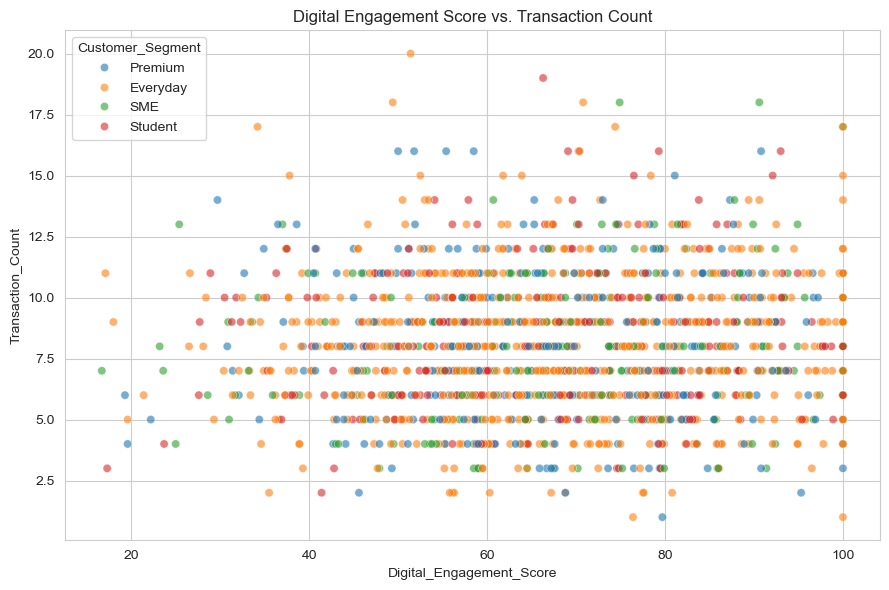

Correlation between engagement score and transaction count: 0.038


In [17]:
## Visualization 7 — Digital Engagement vs. Transaction Activity
# What it shows: the relationship between each customer's Digital_Engagement_Score and how many transactions they actually make, split by segment.

txn_count_per_customer = transactions.groupby('Customer_ID')['Transaction_ID'].count()
txn_count_per_customer = txn_count_per_customer.rename('Transaction_Count')

customer_behaviour = customers.merge(txn_count_per_customer, on='Customer_ID', how='left')
customer_behaviour['Transaction_Count'] = customer_behaviour['Transaction_Count'].fillna(0)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=customer_behaviour, x='Digital_Engagement_Score',
                 y='Transaction_Count', hue='Customer_Segment', alpha=0.6)
plt.title('Digital Engagement Score vs. Transaction Count')
plt.tight_layout()
plt.show()

correlation = customer_behaviour['Digital_Engagement_Score'].corr(customer_behaviour['Transaction_Count'])
print('Correlation between engagement score and transaction count:', round(correlation, 3))

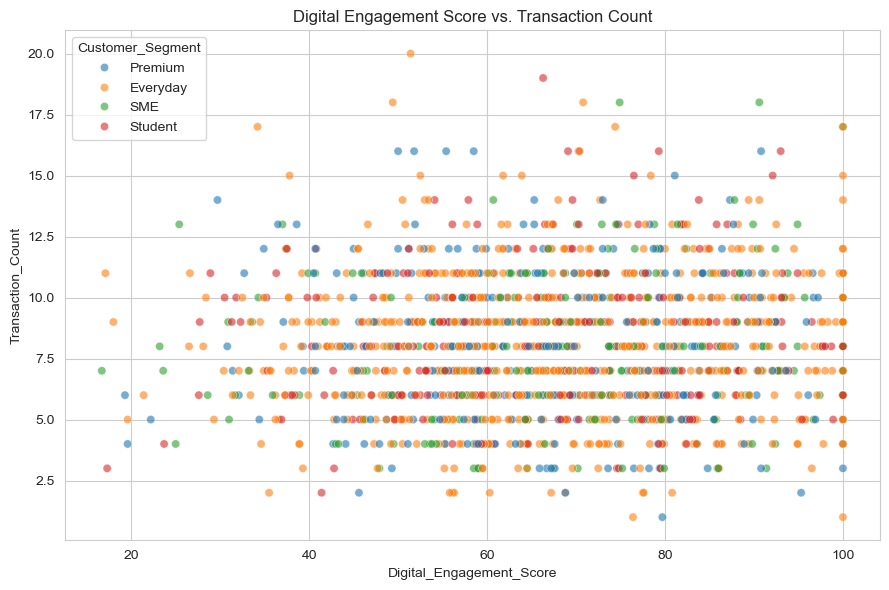

Correlation between engagement score and transaction count: 0.038


In [18]:
## Visualization 7 — Digital Engagement vs. Transaction Activity
# What it shows: the relationship between each customer's Digital_Engagement_Score and how many transactions they actually make, split by segment. 

txn_count_per_customer = transactions.groupby('Customer_ID')['Transaction_ID'].count()
txn_count_per_customer = txn_count_per_customer.rename('Transaction_Count')

customer_behaviour = customers.merge(txn_count_per_customer, on='Customer_ID', how='left')
customer_behaviour['Transaction_Count'] = customer_behaviour['Transaction_Count'].fillna(0)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=customer_behaviour, x='Digital_Engagement_Score',
                 y='Transaction_Count', hue='Customer_Segment', alpha=0.6)
plt.title('Digital Engagement Score vs. Transaction Count')
plt.tight_layout()
plt.show()

correlation = customer_behaviour['Digital_Engagement_Score'].corr(customer_behaviour['Transaction_Count'])
print('Correlation between engagement score and transaction count:', round(correlation, 3))

### Summary of Observations

1. Customer Segment Distribution

Finding: Everyday customers dominate FinTrust's base, nearly half of all customers.
Evidence: 711 of 1,500 customers (47%) are in the Everyday segment, more than double the next-largest, Premium (295).
Business Meaning: Reliability and usability improvements aimed at the "average" user affect the largest share of the customer base by far, while Premium or SME-specific features serve a smaller, more specialized group.

2. Transaction Type — Count vs. Value

Finding: Transfers are both the most frequent and highest-value transaction type, but Deposits punch above their weight on value.
Evidence: Transfers lead on count (3,549) and total value (₦238M). Deposits are 4th on count (1,328) but 2nd on value (₦131M) a far higher value-per-transaction than Card Purchases, which have more than double the count (3,033) but less value (₦86M).
Business Meaning: Transfers deserve the most operational attention (they're both high-volume and high-value), but Deposit failures would be disproportionately costly per incident, while Card Purchase issues would affect more individual customers per incident.

3. Transaction Amount Distribution

Finding: Amount scale varies enormously by type, confirming per-type outlier analysis was the right call.
Evidence: Median transaction value ranges from ₦2,494 (Airtime/Data) to ₦22,094 (Deposit), a 9x difference. The overall dataset also skews right (mean ₦46,706 vs. median ₦10,306), meaning a small number of very large transactions pull the average up.
Business Meaning: Any single flat threshold for "large transaction" would misclassify a normal Deposit as suspicious while missing a genuinely unusual Airtime purchase — type-specific thresholds (as used in Part A) are necessary, not optional.

4. Channel Volume vs. Success Rate

Finding: Mobile App dominates volume but has the lowest success rate of any channel.
Evidence: Mobile App handles 5,102 transactions (43% of all transactions) nearly double the next channel, POS (2,393) but its success rate (89.7%) is the lowest of the five channels, compared to ATM's 91.7%.
Business Meaning: Even a small reliability gap on Mobile App has an outsized real-world impact simply because of scale, this is the single highest-leverage channel for any technical investigation into failed transactions.

5. Transaction Status Breakdown

Finding: The failure/reversal rate is meaningful, not negligible.
Evidence: 90.5% of transactions succeed, but Failed (5.25%) and Reversed (2.7%) together account for just under 8% of all 12,000 transactions, roughly 956 transactions.
Business Meaning: Nearly 1 in 12 transactions doesn't complete cleanly, a rate worth escalating to management as a platform-reliability issue, independent of which channel or type is involved.

6. International vs. Domestic Transactions

Finding: International transactions are far less common but carry almost double the risk-review rate.
Evidence: Only 480 of 12,000 transactions (4%) are international, yet their risk-review rate is 36.9% versus 18.9% for domestic, roughly double, despite a slightly lower average amount (₦41,658 vs. ₦46,917).
Business Meaning: Risk concentrates in international transactions regardless of amount, supporting a policy of routing all cross-border transactions through tighter review by default rather than relying on amount-based thresholds alone (with the reminder this is a synthetic label, not a real fraud determination).

7. Digital Engagement vs. Transaction Activity

Finding: Digital engagement score does not meaningfully predict how often a customer transacts.
Evidence: The correlation between Digital_Engagement_Score and transaction count is 0.038, essentially zero. Average transaction count is nearly identical across all four segments (7.9–8.2 transactions each), despite Premium customers having the lowest average engagement score (66.7) of any segment.
Business Meaning: Digital engagement campaigns likely won't move transaction volume on their own, FinTrust should look at other levers (income band, tenure, account type) if the goal is increasing transaction frequency, rather than assuming "more engaged = more active."

8. Risk-Review Rate by Segment × Channel

Finding: Risk concentrates specifically in Premium customers using the Web channel, not in any segment or channel alone.
Evidence: Premium + Web has the highest risk-review rate in the entire grid at 25.5%, well above the 19.6% overall average while Student + USSD is the lowest at 15.2%. Web is only the highest-risk channel for Premium customers; for Student and SME customers, ATM is actually higher than Web.
Business Meaning: A review policy that targets "Premium customers" or "Web channel" broadly would over-flag a lot of low-risk activity — the real signal is the specific combination, which argues for combination-level rules rather than single-attribute ones.